In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from IPython.display import clear_output
import time as time

In [2]:
map_size = [50,100]
map_resolution = 0.2
extent = [0, map_size[0], 0, map_size[1]]

map_dim = [round(map_size[i]/map_resolution) for i in range(len(map_size))]

In [3]:
# Set parameters for plotting
cmap = ListedColormap(['gray', '#9DC6F2', 'black'])
bounds = [-1.5, -0.5, 0.5, 1.5]
norm = BoundaryNorm(bounds, cmap.N)

### Some useful grid functions

In [4]:
def snap_to_grid(x):
    x0 = map_resolution * round(x[0] / map_resolution)
    x1 = map_resolution * round(x[1] / map_resolution)
    return (x0, x1)

def point_to_grid(x):
    return round(x/map_resolution)

## Generate a occupancy grid with hallways for testing

In [5]:
# Create empty map
occ = np.zeros(map_dim)

# Create outer boundary
occ[0:3,:] = 1
occ[:,0:3] = 1
occ[-3:,:] = 1
occ[:,-3:] = 1

# Create inner barriers
occ[point_to_grid(5):point_to_grid(45), point_to_grid(5):point_to_grid(45)] = 1
occ[point_to_grid(5.5):point_to_grid(44.5), point_to_grid(5.5):point_to_grid(44.5)] = -1

occ[point_to_grid(5):point_to_grid(45), point_to_grid(55):point_to_grid(95)] = 1
occ[point_to_grid(5.5):point_to_grid(44.5), point_to_grid(55.5):point_to_grid(94.5)] = -1

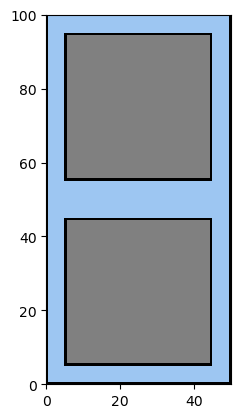

In [6]:
plt.imshow(occ.T, cmap=cmap, norm=norm, interpolation='nearest', origin='lower', extent=extent, aspect='equal')
plt.show()

### Occupancy Grid Class

In [7]:
class StochOccupancyGrid2D(object):
    def __init__(self, resolution, width, height, origin_x, origin_y, window_size, probs, thresh=0.5, robot_d=0.25):
        self.resolution = resolution
        self.width = width
        self.height = height
        self.origin_x = origin_x
        self.origin_y = origin_y
        self.probs = np.reshape(np.asarray(probs), (height, width))
        self.window_size = 10 # window_size
        self.thresh = thresh
        self.robot_d = robot_d

    def snap_to_grid(self, x):
        return (self.resolution*round(x[0]/self.resolution), self.resolution*round(x[1]/self.resolution))

    def snap_to_grid1(self, x):
        return (self.resolution * np.round(x[0] / self.resolution), self.resolution * np.round(x[1] / self.resolution))

    def get_index(self, x):
        return (np.round((x[0]-self.origin_x)/self.resolution), np.round((x[1]-self.origin_y)/self.resolution))

    def is_free(self, state):
        # combine the probabilities of each cell by assuming independence
        # of each estimation
        x, y = self.snap_to_grid(state)
        grid_x = int((x - self.origin_x) / self.resolution)
        grid_y = int((y - self.origin_y) / self.resolution)
        
        # Check if in configuration space
        half_config_size = int(round(self.robot_d/2/self.resolution))
        config_x_lower = max(0, grid_x - half_config_size)
        config_y_lower = max(0, grid_y - half_config_size)
        config_x_upper = min(self.width, grid_x + half_config_size)
        config_y_upper = min(self.height, grid_y + half_config_size)
        
        if np.sum(self.probs[config_y_lower:config_y_upper, config_x_lower:config_x_upper]>0.85):
            return False  # Not free according to configuration space
        elif np.sum(self.probs[config_y_lower:config_y_upper, config_x_lower:config_x_upper]< 0):
            return False
        else:
            return True

    def dist_to_wall_left(self, x, travel_dir):
        return self.dist_to_wall_right(x, [-travel_dir[0], -travel_dir[1]])
    
    def dist_to_wall_right(self, x, travel_dir):
        """
        Return distance (meters) from world position x=(x,y) to the first occupied cell
        found to the right of the travel_dir. If no wall is found inside the map bounds,
        returns 0.
        """
        right = np.array([travel_dir[1], -travel_dir[0]])
        right = right / np.linalg.norm(right)

        # map bounds in meters
        x_min = self.origin_x
        x_max = self.origin_x + self.width * self.resolution
        y_min = self.origin_y
        y_max = self.origin_y + self.height * self.resolution

        # sampling parameters
        step = max(self.resolution * 0.25, 1e-4)   # quarter cell steps (or small eps)
        # maximum distance to search: distance to map border along right direction
        # compute intersection of ray x + t*right with map bounding box to get a safe upper bound
        t_max = 0.0
        # compute candidate distances to each vertical boundary
        if right[0] > 0:
            t_max = max(t_max, (x_max - x[0]) / right[0])
        elif right[0] < 0:
            t_max = max(t_max, (x_min - x[0]) / right[0])
        if right[1] > 0:
            t_max = max(t_max, (y_max - x[1]) / right[1])
        elif right[1] < 0:
            t_max = max(t_max, (y_min - x[1]) / right[1])
        # if right component is 0 that boundary doesn't constrain; t_max may remain 0 if both comps lead outward.
        # ensure positive t_max
        if t_max <= 0:
            # ray immediately points out of bounds — no wall reachable to the right inside the map
            return 100
        if t_max > 15:
            t_max = 15

        # sample along ray
        n_steps = int(np.ceil(t_max / step))
        px = float(x[0])
        py = float(x[1])
        for i in range(1, n_steps + 1):
            t = i * step
            sx = px + right[0] * t
            sy = py + right[1] * t
            # check bounds (small numerical tolerance)
            if sx < x_min or sx >= x_max or sy < y_min or sy >= y_max:
                return 100
            # convert to grid indices (row, col). self.probs indexed as [row(y), col(x)]
            col = int(np.floor((sx - self.origin_x) / self.resolution))
            row = int(np.floor((sy - self.origin_y) / self.resolution))
            # clamp safety
            if row < 0 or row >= self.height or col < 0 or col >= self.width:
                return 100
            if self.probs[row, col] >= self.thresh:
                return t
        return 100

    def plot_grid(self):
        plt.imshow(self.probs, cmap=cmap, norm=norm, interpolation='nearest', origin='lower', extent=extent, aspect='equal')

    def plot_path(self, path):
        xs, ys = zip(*path)
        plt.plot(xs, ys, color='red', linewidth=1, marker=',', zorder=5)
    
    def plot_grid_and_path(self, path):
        self.plot_grid()
        self.plot_path(path)

### A* algorithm

In [8]:
class AStar(object):
    """Represents a motion planning problem to be solved using A*"""

    def __init__(self, statespace_lo, statespace_hi, x_init, x_goal, occupancy, resolution=1):
        self.statespace_lo = np.array(statespace_lo)  # state space lower bound (e.g., [-5, -5])
        self.statespace_hi = np.array(statespace_hi)  # state space upper bound (e.g., [5, 5])
        self.occupancy = occupancy  # occupancy grid (a DetOccupancyGrid2D object)
        self.resolution = resolution  # resolution of the discretization of state space (cell/m)
        self.x_init = self.snap_to_grid(x_init)  # initial state
        self.x_goal = self.snap_to_grid(x_goal)  # goal state

        self.closed_set = set()  # the set containing the states that have been visited
        self.open_set = set()  # the set containing the states that are condidate for future expension
        self.came_from = {}  # dictionary keeping track of each state's parent to reconstruct the path
        self.est_cost_through = {}
        self.cost_to_arrive = {}

        self.open_set.add(self.x_init)
        self.cost_to_arrive[self.x_init] = 0
        self.est_cost_through[self.x_init] = self.distance(self.x_init, self.x_goal)

        self.path = None  # the final path as a list of states
        self.pp_plan = None  # the post-processed plan

    def is_free(self, x):
        """
        Checks if a give state x is free, meaning it is inside the bounds of the map and
        is not inside any obstacle.
        Inputs:
            x: state tuple
        Output:
            Boolean True/False
        """
        if self.occupancy.is_free(x) and self.statespace_lo[0] <= x[0] < self.statespace_hi[1] and self.statespace_lo[1] <= x[1] < self.statespace_hi[1]:
            return True
        else:
            return False

    def distance(self, x1, x2):
        """
        Computes the Euclidean distance between two states.
        Inputs:
            x1: First state tuple
            x2: Second state tuple
        Output:
            Float Euclidean distance
        """
        return np.linalg.norm(np.array(x1) - np.array(x2))

    def manhattan_distance(self, x1, x2):
        """
        Computes the Manhattan distance between two states.
        Inputs:
            x1: First state tuple
            x2: Second state tuple
        Output:
            Float Manhattan distance
        """
        return np.sum(np.abs(np.array(x1) - np.array(x2)))

    def rightness_penalty(self, x1, x2):
        """
        Computes the heuristic distance between two states.
        Inputs:
            x1: First state tuple
            x2: Second state tuple
        Output:
            Float: heuristic distance
        """
        travel_dir = (np.array(x2) - np.array(x1)) / np.linalg.norm(np.array(x2) - np.array(x1))
        dist_to_right = self.occupancy.dist_to_wall_right(x2, travel_dir)
        return dist_to_right

    def leftness_penalty(self, x1, x2):
        travel_dir = (np.array(x2) - np.array(x1)) / np.linalg.norm(np.array(x2) - np.array(x1))
        dist_to_left = self.occupancy.dist_to_wall_left(x2, travel_dir)
        return dist_to_left
    
    def snap_to_grid(self, x):
        """ Returns the closest point on a discrete state grid
        Input:
            x: tuple state
        Output:
            A tuple that represents the closest point to x on the discrete state grid
        """
        return (self.resolution * round(x[0] / self.resolution), self.resolution * round(x[1] / self.resolution))

    def get_neighbors(self, x, step_resolution=1):
        """
        Gets the FREE neighbor states of a given state x. Assumes a motion model
        where we can move up, down, left, right, or along the diagonals by an
        amount equal to self.resolution.
        Input:
            x: tuple state
        Ouput:
            List of neighbors that are free, as a list of TUPLES
        """
        neighbors = []
        for ii in [1, 0, -1]:
            for jj in [1, 0, -1]:
                if ii != 0 or jj != 0:
                    x0 = x[0]
                    x1 = x[1]
                    x0 += ii * self.resolution   # /(np.linalg.norm(np.array((ii, jj))))
                    x1 += jj * self.resolution   # /(np.linalg.norm(np.array((ii, jj))))
                    state = self.snap_to_grid((x0, x1))
                    if self.is_free(state):
                        neighbors.append(state)
        return neighbors

    def find_best_est_cost_through(self):
        """
        Gets the state in open_set that has the lowest est_cost_through
        Output: A tuple, the state found in open_set that has the lowest est_cost_through
        """
        return min(self.open_set, key=lambda x: self.est_cost_through[x])

    def reconstruct_path(self):
        """
        Use the came_from map to reconstruct a path from the initial location to
        the goal location
        Output:
            A list of tuples, which is a list of the states that go from start to goal
        """
        path = [self.x_goal]
        current = path[-1]
        while current != self.x_init:
            path.append(self.came_from[current])
            current = path[-1]

        return list(reversed(path))

    def solve(self, plot=False):
        """
        Solves the planning problem using the A* search algorithm. It places
        the solution as a list of tuples (each representing a state) that go
        from self.x_init to self.x_goal inside the variable self.path
        Input:
            None
        Output:
            Boolean, True if a solution from x_init to x_goal was found
        """        
        time_limit = 60

        self.x_recorded = []
        self.x_vector = []
        self.x_right_cost = []

        start = time.time()        
        while len(self.open_set) > 0:
            if time.time() - start > time_limit:
                print("A* took too long")
                return False
        
            x_current = self.find_best_est_cost_through()
            if x_current == self.x_goal:
                self.path = self.reconstruct_path()
                return True
            self.open_set.remove(x_current)
            self.closed_set.add(x_current)
            for x_neigh in self.get_neighbors(x_current):
                # right_cost = 0.002*self.rightness_penalty(x_current, x_neigh)
                # left_cost = self.leftness_penalty(x_current, x_neigh)
                tentative_cost_to_arrive = self.cost_to_arrive[x_current] + self.distance(x_current, x_neigh)
                # self.x_recorded.append(x_neigh)
                # self.x_vector.append((np.array(x_neigh) - np.array(x_current)) / np.linalg.norm(np.array(x_neigh) - np.array(x_current)))
                # self.x_right_cost.append(right_cost)
                if x_neigh not in self.cost_to_arrive or tentative_cost_to_arrive < self.cost_to_arrive[x_neigh]:
                    self.open_set.add(x_neigh)
                    self.came_from[x_neigh] = x_current
                    self.cost_to_arrive[x_neigh] = tentative_cost_to_arrive
                    self.est_cost_through[x_neigh] = tentative_cost_to_arrive + self.manhattan_distance(x_neigh, self.x_goal)
        return False

    
    def postprocess(self):
        """
        Function for postprocessing the planned path. It examines each planned point, computes the nearest point to the right,
        and if close enough, moves the point to the right. The post-processed plan is placed into the self.pp_plan variable.
        Input: 
            None
        Output: 
            None
        """
        self.pp_path = []
        self.pp_path.append(self.path[0])

        for ii in range(len(self.path)-1):
            dist_to_right = self.rightness_penalty(self.path[ii], self.path[ii+1])
            if dist_to_right < 10.1:
                # 1. Get the start and end points of the segment
                p1 = np.array(self.path[ii])
                p2 = np.array(self.path[ii+1]) # The point we are conceptually moving
        
                # 2. Calculate the direction vector of the path segment
                direction_vec = p2 - p1
                
                # Avoid division by zero if points are identical
                dir_magnitude = np.linalg.norm(direction_vec)
                if dir_magnitude < 1e-6:
                    continue

                # 3. Get the perpendicular "RIGHT" vector
                # If direction is (dx, dy), the vector to the right is (dy, -dx)
                right_vec = np.array([direction_vec[1], -direction_vec[0]])
                
                # 4. Normalize the "right" vector to get a pure direction (unit vector)
                unit_right_vec = right_vec / np.linalg.norm(right_vec)
                
                # 5. Calculate the new point by shifting the original point to the right
                new_point = p2 + unit_right_vec * dist_to_right
                
                self.pp_path.append(self.snap_to_grid((new_point[0], new_point[1])))
            else:
                self.pp_path.append(self.path[ii+1])
        return 

        def postprocess2(self):
            """
            Function for postprocessing the planned path. It examines each planned point, computes the nearest point to the right,
            and if close enough, moves the point to the right. The post-processed plan is placed into the self.pp_plan variable.
            Input: 
                None
            Output: 
                None
            """
            self.pp_path = []
            self.pp_path.append(self.path[0])
    
            for ii in range(len(self.path)-1):
                dist_to_right = self.rightness_penalty(self.path[ii], self.path[ii+1])
                if dist_to_right < 10.1:
                    # 1. Get the start and end points of the segment
                    p1 = np.array(self.path[ii])
                    p2 = np.array(self.path[ii+1]) # The point we are conceptually moving
            
                    # 2. Calculate the direction vector of the path segment
                    direction_vec = p2 - p1
                    
                    # Avoid division by zero if points are identical
                    dir_magnitude = np.linalg.norm(direction_vec)
                    if dir_magnitude < 1e-6:
                        continue
    
                    # 3. Get the perpendicular "RIGHT" vector
                    # If direction is (dx, dy), the vector to the right is (dy, -dx)
                    right_vec = np.array([direction_vec[1], -direction_vec[0]])
                    
                    # 4. Normalize the "right" vector to get a pure direction (unit vector)
                    unit_right_vec = right_vec / np.linalg.norm(right_vec)
                    
                    # 5. Calculate the new point by shifting the original point to the right
                    new_point = p2 + unit_right_vec * dist_to_right
                    
                    self.pp_path.append((new_point[0], new_point[1]))
                else:
                    self.pp_path.append(self.path[ii+1])
            return 

### Perform A* on the map

In [9]:
# Create occupancy grid object
occ_grid = StochOccupancyGrid2D(map_resolution, map_dim[0], map_dim[1], 0, 0, 10, occ.T)

In [10]:
# Create A* Problem
x_init = snap_to_grid([3,3])
x_goal = snap_to_grid([47, 97])
problem = AStar([0,0], snap_to_grid(map_size), x_init, x_goal, occ_grid, resolution=map_resolution)

In [11]:
problem.solve()

True

In [12]:
planned_path = problem.path

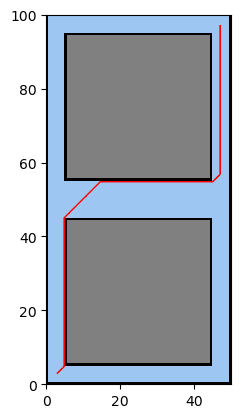

In [13]:
# Plot the planned path
plt.figure(2)
occ_grid.plot_grid_and_path(planned_path)
plt.show()

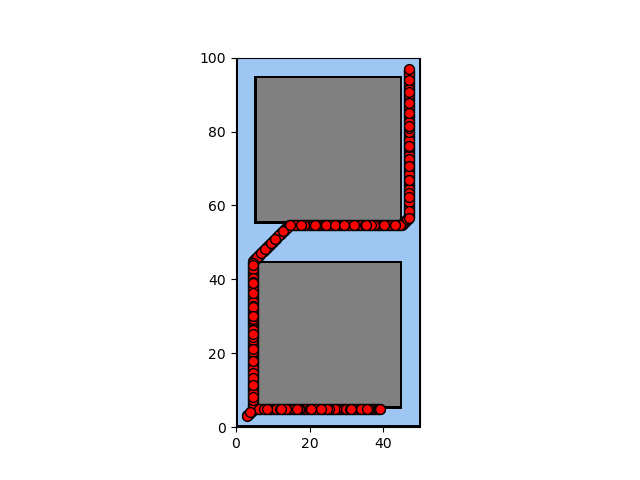

In [15]:
# Plot all points placed into the closed set
plt.figure(3)
occ_grid.plot_grid()
closed_set = problem.closed_set
xs, ys = zip(*closed_set)          # unzip into two sequences
plt.scatter(xs, ys, s=50, c='red', marker='o', edgecolor='k', zorder=5)
plt.gca().set_aspect('equal')
plt.show()

In [16]:
pts = np.asarray(problem.x_recorded)
vecs = np.asarray(problem.x_vector)
costs = np.asarray(problem.x_right_cost)
step = 300
idx = np.arange(0, pts.shape[0], step)   # every 10th index
pts = pts[idx]
vecs = vecs[idx]
costs = costs[idx]

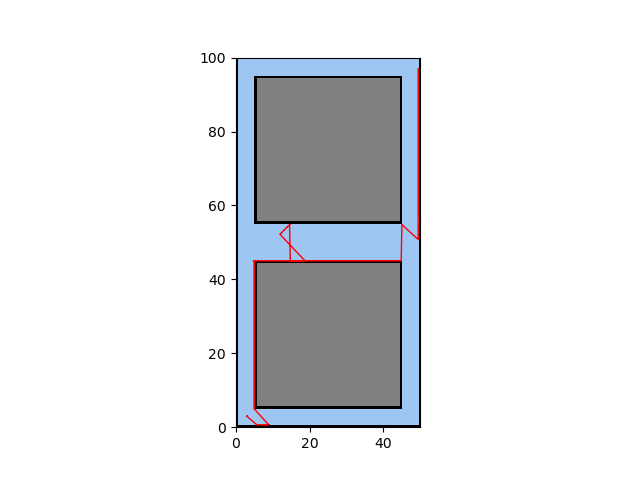

In [17]:
# Create the postprocessed path and plot it
problem.postprocess()

plt.figure(4)
occ_grid.plot_grid_and_path(problem.pp_path)
plt.show()

In [ ]:
arrow_length = 10  # meters (tweak as needed)
U = vecs[:, 0] * arrow_length
V = vecs[:, 1] * arrow_length

In [ ]:
plt.figure(figsize=(8,6))
occ_grid.plot_grid()
Q = plt.quiver(pts[:,0], pts[:,1], U, V, costs,
               cmap='viridis', scale=1, scale_units='xy', angles='xy', pivot='middle')

plt.colorbar(Q, label='right cost')
plt.gca().set_aspect('equal')
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.show()

In [18]:
from IPython.display import display, clear_output

In [23]:
grid = np.zeros((10, 10))
start = (0, 0)
goal = (9, 9)

fig, ax = plt.subplots()
ax.imshow(grid, cmap='gray_r')

ax.scatter(start[1], start[0], c='green', label='Start')
ax.scatter(goal[1], goal[0], c='red', label='Goal')
ax.legend()

display(fig)  # Display the figure once

# Simulate incremental exploration
for i in range(10):
    for j in range(10):
        ax.scatter(j, i, c='blue', s=10)  # Add new explored point
        clear_output(wait=True)
        display(fig)
        time.sleep(0.001)

KeyboardInterrupt: 